# Análisis Exploratorio de Indicadores de Calidad del Agua
## Variable Respuesta: pH del Agua

---

**Curso:** Python para Ciencia de Datos  
**Dataset:** Water Quality Testing  
**Variable objetivo:** pH

---

## Contenido

- [1. Introducción](#1-introduccion)
- [2. Objetivo del Análisis](#2-objetivo)
- [3. Marco Teórico](#3-marco-teorico)
- [4. Análisis Exploratorio de Datos (EDA)](#4-eda)
  - [4.1 Importación de librerías](#41-librerias)
  - [4.2 Carga del dataset](#42-carga)
  - [4.3 Estructura y dimensiones](#43-estructura)
  - [4.4 Clasificación de variables](#44-clasificacion)
  - [4.5 Calidad de datos](#45-calidad)
  - [4.6 Resumen estadístico](#46-estadistico)
  - [4.7 Variable objetivo: pH](#47-objetivo)
  - [4.8 Análisis univariado](#48-univariado)
  - [4.9 Análisis bivariado](#49-bivariado)
  - [4.10 Análisis de correlación](#410-correlacion)
- [5. Conclusiones](#5-conclusiones)

---
## 1. Introducción <a id='1-introduccion'></a>

El agua es uno de los recursos más fundamentales para la vida y el desarrollo humano. Garantizar su calidad no es solo una cuestión ambiental, sino también un tema de salud pública, economía y sostenibilidad. La monitorización de parámetros fisicoquímicos del agua permite detectar condiciones de riesgo, orientar decisiones de tratamiento y proteger ecosistemas acuáticos.

El **pH** es uno de los indicadores más relevantes en la evaluación de la calidad del agua. Un valor de pH fuera del rango aceptable (6.5 – 8.5 según la OMS) puede afectar la solubilidad de metales pesados, alterar la eficacia de procesos de desinfección, y ser perjudicial tanto para la vida acuática como para el consumo humano.

Este análisis exploratorio busca comprender el comportamiento del pH en una muestra de 500 registros de pruebas de calidad del agua, identificando sus distribución, relaciones con otras variables fisicoquímicas y posibles patrones que orienten análisis posteriores.

---
## 2. Objetivo del Análisis <a id='2-objetivo'></a>

### 2.1 Objetivo General
Realizar un análisis exploratorio de datos (EDA) sobre un dataset de calidad del agua, tomando el **pH** como variable respuesta, con el fin de describir su distribución y analizar sus relaciones con los demás parámetros fisicoquímicos registrados.

### 2.2 Objetivos Específicos
- Examinar la estructura, dimensiones y tipos de variables del dataset.
- Verificar la calidad de los datos: valores nulos, duplicados y rangos esperados.
- Describir estadísticamente cada variable, incluyendo asimetría y curtosis.
- Analizar la distribución del pH mediante visualizaciones univariadas.
- Explorar las relaciones bivariadas entre el pH y las demás variables fisicoquímicas.
- Evaluar la fuerza y dirección de las correlaciones entre variables.

---
## 3. Marco Teórico <a id='3-marco-teorico'></a>

### 3.1 El pH como parámetro de calidad del agua

El **pH** (potencial de hidrógeno) es una medida de la acidez o basicidad de una solución, con una escala que va de 0 a 14. Para el agua potable, la Organización Mundial de la Salud (OMS) recomienda un rango de **6.5 a 8.5**. Valores fuera de este rango pueden:
- Favorecer la corrosión de tuberías (pH bajo)
- Precipitar minerales y alterar el sabor (pH alto)
- Afectar la eficacia del cloro como desinfectante
- Impactar la supervivencia de organismos acuáticos

### 3.2 Parámetros fisicoquímicos relacionados

| Parámetro | Descripción | Rango típico |
|---|---|---|
| **pH** | Acidez/basicidad del agua | 6.5 – 8.5 (OMS) |
| **Temperatura (°C)** | Afecta solubilidad de gases y reacciones químicas | 10 – 30 °C |
| **Turbidez (NTU)** | Material suspendido; indica contaminación | < 5 NTU (potable) |
| **Oxígeno Disuelto (mg/L)** | Esencial para vida acuática | > 6 mg/L (buena calidad) |
| **Conductividad (µS/cm)** | Refleja concentración de iones disueltos | 50 – 500 µS/cm (potable) |

### 3.3 El Análisis Exploratorio de Datos (EDA)

El EDA, propuesto por John Tukey (1977), es una filosofía de análisis que enfatiza el uso de técnicas gráficas y estadísticas descriptivas para entender los datos antes de modelarlos. Sus componentes principales son:
- **Análisis univariado:** distribución y estadísticas de cada variable por separado.
- **Análisis bivariado:** relaciones entre pares de variables.
- **Análisis de correlación:** medición de la fuerza de las asociaciones lineales.

Un EDA robusto permite identificar valores atípicos, sesgos, relaciones no esperadas y orientar la selección de modelos estadísticos.

---
## 4. Análisis Exploratorio de Datos (EDA) <a id='4-eda'></a>

### 4.1 Importación de librerías <a id='41-librerias'></a>

In [2]:
# ─── Librerías principales ───────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ─── Visualización ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ─── Estadística ────────────────────────────────────────────────────────────
from scipy import stats

# ─── Configuración global ───────────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Paleta de colores personalizada
PALETTE = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
COLOR_PH  = '#2196F3'   # azul agua para la variable objetivo

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


### 4.2 Carga del dataset <a id='42-carga'></a>

In [3]:
# ─── Carga del dataset ───────────────────────────────────────────────────────
# Si estás en Google Colab, sube el archivo con:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Water Quality Testing.csv')

print(f'✅ Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
print()
print('Vista inicial del dataset:')
df.head()

Mounted at /content/drive
✅ Dataset cargado: 500 filas × 6 columnas

Vista inicial del dataset:


,Sample ID,pH,Temperature (°C),Turbidity (NTU),Dissolved Oxygen (mg/L),Conductivity (µS/cm)
0,1,7.2500,23.1000,4.5000,7.8000,342
1,2,7.1100,22.3000,5.1000,6.2000,335
2,3,7.0300,21.5000,3.9000,8.3000,356
3,4,7.3800,22.9000,3.2000,9.5000,327
4,5,7.4500,20.7000,3.8000,8.1000,352


### 4.3 Estructura y dimensiones <a id='43-estructura'></a>

In [4]:
# ─── Dimensiones ─────────────────────────────────────────────────────────────
print('=' * 50)
print(f'  Filas    : {df.shape[0]}')
print(f'  Columnas : {df.shape[1]}')
print('=' * 50)

  Filas    : 500
  Columnas : 6


In [5]:
# ─── Tipos de datos y valores no nulos ───────────────────────────────────────
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Sample ID                500 non-null    int64  
 1   pH                       500 non-null    float64
 2   Temperature (°C)         500 non-null    float64
 3   Turbidity (NTU)          500 non-null    float64
 4   Dissolved Oxygen (mg/L)  500 non-null    float64
 5   Conductivity (µS/cm)     500 non-null    int64  
dtypes: float64(4), int64(2)
memory usage: 23.6 KB


### 4.4 Clasificación de variables <a id='44-clasificacion'></a>

In [6]:
# ─── Clasificación manual de variables ───────────────────────────────────────
var_id         = ['Sample ID']                             # identificador
var_respuesta  = ['pH']                                    # variable objetivo
var_continuas  = ['Temperature (°C)', 'Turbidity (NTU)',
                  'Dissolved Oxygen (mg/L)']               # numéricas continuas
var_discretas  = ['Conductivity (µS/cm)']                  # numérica discreta (entero)

print('─' * 55)
print(f'  Variable identificadora  : {var_id}')
print(f'  Variable respuesta (pH)  : {var_respuesta}')
print(f'  Variables continuas      : {var_continuas}')
print(f'  Variables discretas      : {var_discretas}')
print('─' * 55)

───────────────────────────────────────────────────────
  Variable identificadora  : ['Sample ID']
  Variable respuesta (pH)  : ['pH']
  Variables continuas      : ['Temperature (°C)', 'Turbidity (NTU)', 'Dissolved Oxygen (mg/L)']
  Variables discretas      : ['Conductivity (µS/cm)']
───────────────────────────────────────────────────────


In [7]:
# ─── Diccionario de variables ─────────────────────────────────────────────────
diccionario = pd.DataFrame({
    'Variable': df.columns,
    'Tipo Python': df.dtypes.values,
    'Clasificación': ['Identificador', 'Numérica continua (OBJETIVO)',
                      'Numérica continua', 'Numérica continua',
                      'Numérica continua', 'Numérica discreta'],
    'Descripción': [
        'Número de muestra único (1–500)',
        'Potencial de hidrógeno (acidez/basicidad)',
        'Temperatura del agua en grados Celsius',
        'Turbidez: material suspendido en unidades NTU',
        'Concentración de oxígeno disuelto en mg/L',
        'Conductividad eléctrica del agua en µS/cm'
    ],
    'Rango esperado': [
        '1 – 500', '6.5 – 8.5 (OMS)', '0 – 40 °C',
        '0 – 1000 NTU', '0 – 14 mg/L', '0 – 2000 µS/cm'
    ]
})

diccionario

,Variable,Tipo Python,Clasificación,Descripción,Rango esperado
0,Sample ID,int64,Identificador,Número de muestra único (1–500),1 – 500
1,pH,float64,Numérica continua (OBJETIVO),Potencial de hidrógeno (acidez/basicidad),6.5 – 8.5 (OMS)
2,Temperature (°C),float64,Numérica continua,Temperatura del agua en grados Celsius,0 – 40 °C
3,Turbidity (NTU),float64,Numérica continua,Turbidez: material suspendido en unidades NTU,0 – 1000 NTU
4,Dissolved Oxygen (mg/L),float64,Numérica continua,Concentración de oxígeno disuelto en mg/L,0 – 14 mg/L
5,Conductivity (µS/cm),int64,Numérica discreta,Conductividad eléctrica del agua en µS/cm,0 – 2000 µS/cm


### 4.5 Limpieza y verificación de calidad de datos <a id='45-calidad'></a>

In [8]:
# ─── 4.5.1 Valores nulos ─────────────────────────────────────────────────────
nulos = pd.DataFrame({
    'Nulos absolutos': df.isnull().sum(),
    'Porcentaje (%)' : (df.isnull().sum() / len(df) * 100).round(2)
})

print('Valores nulos por variable:')
print(nulos)
print()
if nulos['Nulos absolutos'].sum() == 0:
    print('✅ No se encontraron valores nulos en el dataset.')
else:
    print('⚠️  Se encontraron valores nulos. Requieren tratamiento.')

Valores nulos por variable:
                         Nulos absolutos  Porcentaje (%)
Sample ID                              0          0.0000
pH                                     0          0.0000
Temperature (°C)                       0          0.0000
Turbidity (NTU)                        0          0.0000
Dissolved Oxygen (mg/L)                0          0.0000
Conductivity (µS/cm)                   0          0.0000

✅ No se encontraron valores nulos en el dataset.


In [9]:
# ─── 4.5.2 Registros duplicados ──────────────────────────────────────────────
duplicados = df.duplicated().sum()
print(f'Registros duplicados: {duplicados}')

if duplicados == 0:
    print('✅ No existen registros duplicados.')
else:
    print(f'⚠️  Se encontraron {duplicados} duplicados. Se recomienda eliminarlos.')

Registros duplicados: 0
✅ No existen registros duplicados.


In [10]:
# ─── 4.5.3 Verificación de rangos esperados ──────────────────────────────────
rangos_esperados = {
    'pH'                     : (0, 14),
    'Temperature (°C)'       : (0, 40),
    'Turbidity (NTU)'        : (0, 1000),
    'Dissolved Oxygen (mg/L)': (0, 14),
    'Conductivity (µS/cm)'   : (0, 2000)
}

print('Verificación de rangos:')
print(f'  {"Variable":<30} {"Min":>8} {"Max":>8}  {"Fuera de rango":>15}')
print('  ' + '-' * 65)
for col, (lo, hi) in rangos_esperados.items():
    fuera = ((df[col] < lo) | (df[col] > hi)).sum()
    estado = '✅ OK' if fuera == 0 else f'⚠️  {fuera} registros'
    print(f'  {col:<30} {df[col].min():>8.2f} {df[col].max():>8.2f}  {estado:>15}')

Verificación de rangos:
  Variable                            Min      Max   Fuera de rango
  -----------------------------------------------------------------
  pH                                 6.83     7.48             ✅ OK
  Temperature (°C)                  20.30    23.60             ✅ OK
  Turbidity (NTU)                    3.10     5.10             ✅ OK
  Dissolved Oxygen (mg/L)            6.00     9.90             ✅ OK
  Conductivity (µS/cm)             316.00   370.00             ✅ OK


In [11]:
# ─── 4.5.4 Valores atípicos (método IQR) ─────────────────────────────────────
columnas_num = ['pH', 'Temperature (°C)', 'Turbidity (NTU)',
                'Dissolved Oxygen (mg/L)', 'Conductivity (µS/cm)']

resultados_iqr = []
for col in columnas_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    n_atipicos = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    resultados_iqr.append({
        'Variable': col, 'Q1': round(Q1,3), 'Q3': round(Q3,3),
        'IQR': round(IQR,3), 'Límite inf.': round(lim_inf,3),
        'Límite sup.': round(lim_sup,3), 'Atípicos': n_atipicos
    })

pd.DataFrame(resultados_iqr).set_index('Variable')

,Q1,Q3,IQR,Límite inf.,Límite sup.,Atípicos
Variable,,,,,,
pH,7.0800,7.2500,0.1700,6.8250,7.5050,0
Temperature (°C),21.2000,22.9000,1.7000,18.6500,25.4500,0
Turbidity (NTU),3.8000,4.5000,0.7000,2.7500,5.5500,0
Dissolved Oxygen (mg/L),7.8000,9.1000,1.3000,5.8500,11.0500,0
Conductivity (µS/cm),333.0000,355.0000,22.0000,300.0000,388.0000,0


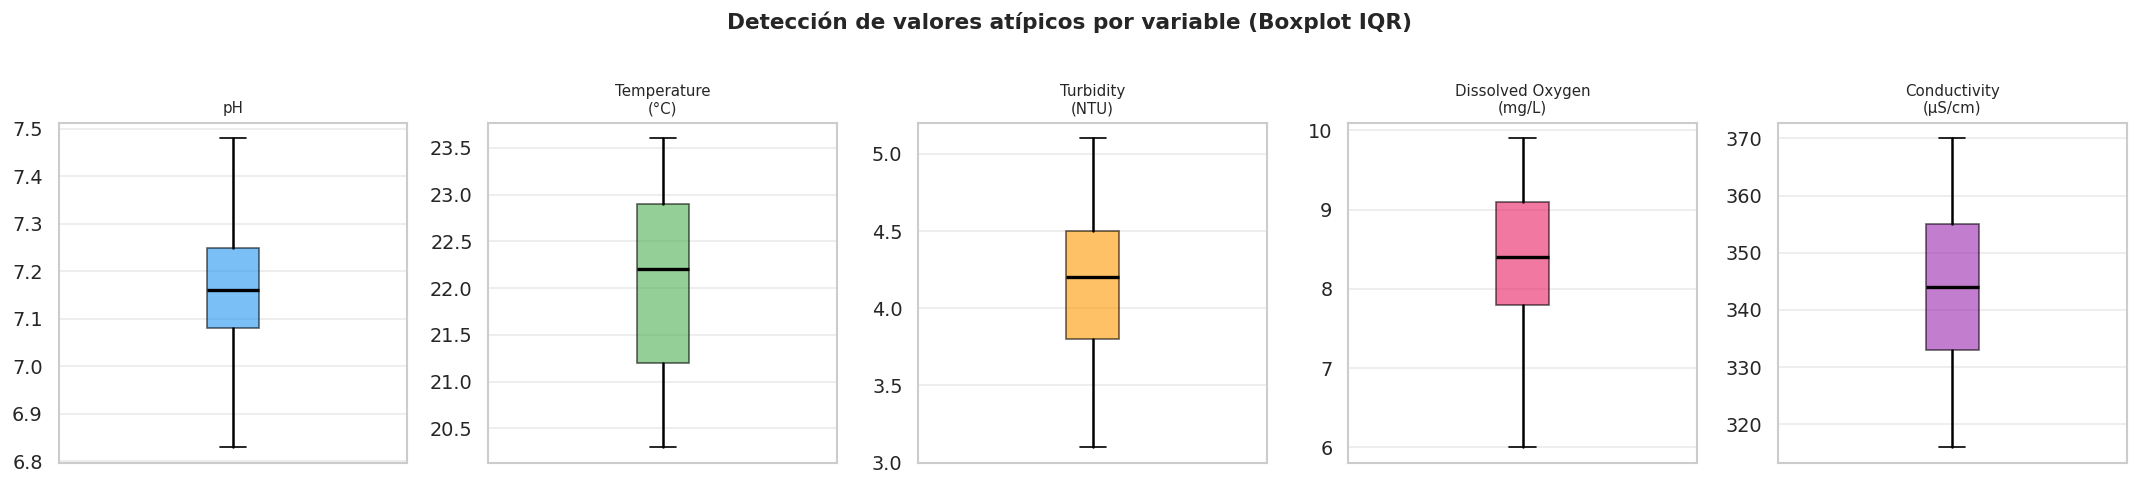

In [12]:
# ─── Boxplots para visualizar atípicos ───────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, col, color in zip(axes, columnas_num, PALETTE):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               whiskerprops=dict(linewidth=1.5),
               flierprops=dict(marker='o', markerfacecolor='red',
                               markersize=5, alpha=0.7))
    ax.set_title(col.replace(' (', '\n('), fontsize=9)
    ax.set_xticks([])
    ax.grid(axis='y', alpha=0.4)

fig.suptitle('Detección de valores atípicos por variable (Boxplot IQR)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.6 Resumen estadístico <a id='46-estadistico'></a>

In [13]:
# ─── Estadísticas descriptivas completas ─────────────────────────────────────
df[columnas_num].describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
pH,500.0000,7.1611,0.1075,6.8300,7.0800,7.1600,7.2500,7.4800
Temperature (°C),500.0000,22.0544,0.9031,20.3000,21.2000,22.2000,22.9000,23.6000
Turbidity (NTU),500.0000,4.1694,0.3975,3.1000,3.8000,4.2000,4.5000,5.1000
Dissolved Oxygen (mg/L),500.0000,8.3822,0.8224,6.0000,7.8000,8.4000,9.1000,9.9000
Conductivity (µS/cm),500.0000,344.3620,13.0387,316.0000,333.0000,344.0000,355.0000,370.0000


In [14]:
# ─── 4.6.1 Asimetría y Curtosis ──────────────────────────────────────────────
resumen_forma = pd.DataFrame({
    'Asimetría (Skewness)': df[columnas_num].skew().round(4),
    'Curtosis (Kurtosis)' : df[columnas_num].kurt().round(4)
})

# Interpretación
def interpretar_asimetria(s):
    if abs(s) < 0.5:  return 'Simétrica'
    elif s < -0.5:    return 'Sesgada izq.'
    else:             return 'Sesgada der.'

def interpretar_curtosis(k):
    if abs(k) < 1: return 'Mesocúrtica (normal)'
    elif k > 1:    return 'Leptocúrtica (colas pesadas)'
    else:          return 'Platicúrtica (colas ligeras)'

resumen_forma['Interpretación asim.'] = resumen_forma['Asimetría (Skewness)'].apply(interpretar_asimetria)
resumen_forma['Interpretación curt.'] = resumen_forma['Curtosis (Kurtosis)'].apply(interpretar_curtosis)

print('Forma de las distribuciones:')
resumen_forma

Forma de las distribuciones:


,Asimetría (Skewness),Curtosis (Kurtosis),Interpretación asim.,Interpretación curt.
pH,0.0897,-0.6018,Simétrica,Mesocúrtica (normal)
Temperature (°C),-0.1421,-1.3287,Simétrica,Platicúrtica (colas ligeras)
Turbidity (NTU),-0.3081,-0.7612,Simétrica,Mesocúrtica (normal)
Dissolved Oxygen (mg/L),-0.2354,-0.5772,Simétrica,Mesocúrtica (normal)
Conductivity (µS/cm),0.1004,-1.0512,Simétrica,Platicúrtica (colas ligeras)


### 4.7 Variable objetivo: pH <a id='47-objetivo'></a>

In [15]:
# ─── Estadísticas detalladas del pH ──────────────────────────────────────────
ph = df['pH']

print('═' * 50)
print('   ESTADÍSTICAS DE LA VARIABLE OBJETIVO: pH')
print('═' * 50)
print(f'  Registros     : {ph.count()}')
print(f'  Media         : {ph.mean():.4f}')
print(f'  Mediana       : {ph.median():.4f}')
print(f'  Desv. estándar: {ph.std():.4f}')
print(f'  Mínimo        : {ph.min():.4f}')
print(f'  Máximo        : {ph.max():.4f}')
print(f'  Asimetría     : {ph.skew():.4f}')
print(f'  Curtosis      : {ph.kurt():.4f}')
print('─' * 50)
# Clasificación según OMS
fuera_oms = ((ph < 6.5) | (ph > 8.5)).sum()
dentro    = (ph.count() - fuera_oms)
print(f'  Dentro rango OMS (6.5–8.5) : {dentro} ({dentro/ph.count()*100:.1f}%)')
print(f'  Fuera rango OMS            : {fuera_oms} ({fuera_oms/ph.count()*100:.1f}%)')
print('═' * 50)

══════════════════════════════════════════════════
   ESTADÍSTICAS DE LA VARIABLE OBJETIVO: pH
══════════════════════════════════════════════════
  Registros     : 500
  Media         : 7.1611
  Mediana       : 7.1600
  Desv. estándar: 0.1075
  Mínimo        : 6.8300
  Máximo        : 7.4800
  Asimetría     : 0.0897
  Curtosis      : -0.6018
──────────────────────────────────────────────────
  Dentro rango OMS (6.5–8.5) : 500 (100.0%)
  Fuera rango OMS            : 0 (0.0%)
══════════════════════════════════════════════════


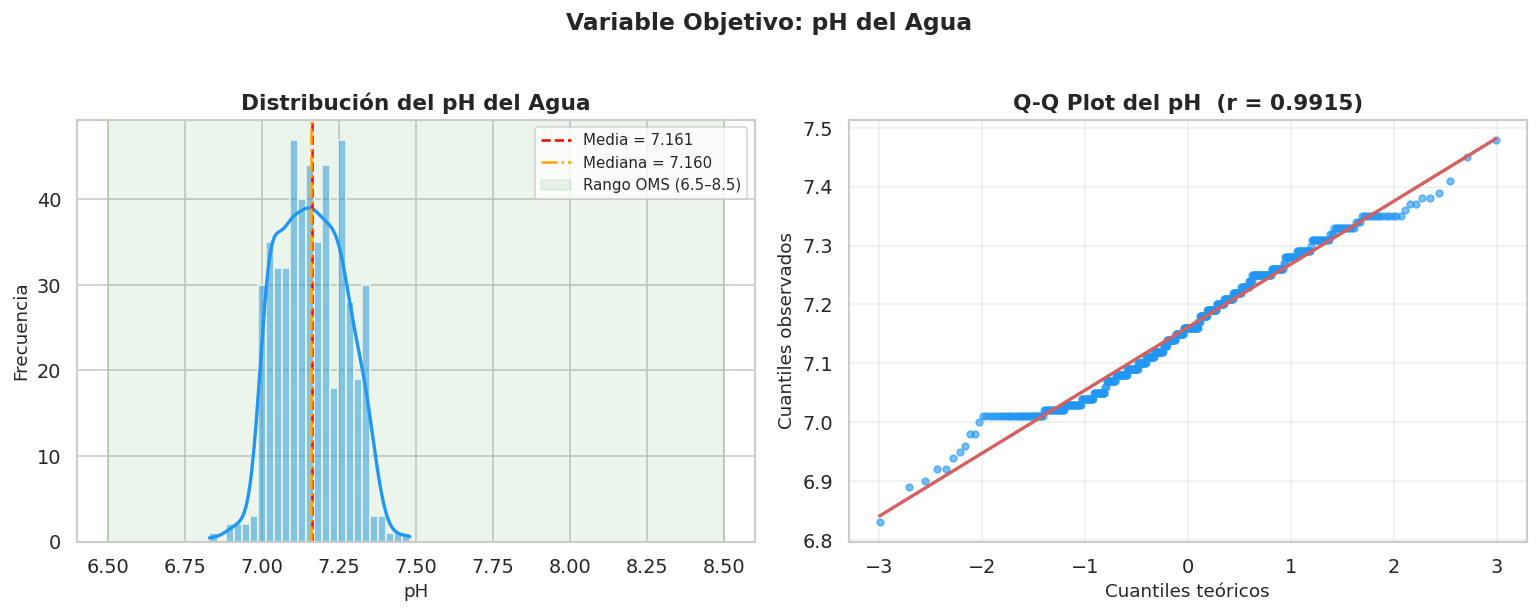


Prueba Shapiro-Wilk (n=50): estadístico = 0.9299, p-valor = 0.0055
⚠️  Se rechaza la hipótesis de normalidad (p ≤ 0.05)


In [16]:
# ─── Distribución del pH: histograma + KDE + Q-Q plot ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma + KDE
ax = axes[0]
sns.histplot(ph, kde=True, color=COLOR_PH, bins=25, ax=ax,
             line_kws={'linewidth': 2})
ax.axvline(ph.mean(),   color='red',    linestyle='--', linewidth=1.5,
           label=f'Media = {ph.mean():.3f}')
ax.axvline(ph.median(), color='orange', linestyle='-.',  linewidth=1.5,
           label=f'Mediana = {ph.median():.3f}')
ax.axvspan(6.5, 8.5, alpha=0.08, color='green',
           label='Rango OMS (6.5–8.5)')
ax.set_title('Distribución del pH del Agua', fontweight='bold')
ax.set_xlabel('pH')
ax.set_ylabel('Frecuencia')
ax.legend(fontsize=9)

# Q-Q Plot (normalidad)
ax2 = axes[1]
(osm, osr), (slope, intercept, r) = stats.probplot(ph, dist='norm')
ax2.plot(osm, osr, 'o', color=COLOR_PH, alpha=0.6, markersize=4)
ax2.plot(osm, slope * np.array(osm) + intercept, 'r-', linewidth=2)
ax2.set_title(f'Q-Q Plot del pH  (r = {r:.4f})', fontweight='bold')
ax2.set_xlabel('Cuantiles teóricos')
ax2.set_ylabel('Cuantiles observados')
ax2.grid(True, alpha=0.3)

fig.suptitle('Variable Objetivo: pH del Agua', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Prueba de normalidad Shapiro-Wilk (muestra)
muestra = ph.sample(50, random_state=42)
stat, p = stats.shapiro(muestra)
print(f'\nPrueba Shapiro-Wilk (n=50): estadístico = {stat:.4f}, p-valor = {p:.4f}')
if p > 0.05:
    print('✅ No se rechaza normalidad (p > 0.05)')
else:
    print('⚠️  Se rechaza la hipótesis de normalidad (p ≤ 0.05)')

### 4.8 Análisis univariado de todas las variables <a id='48-univariado'></a>

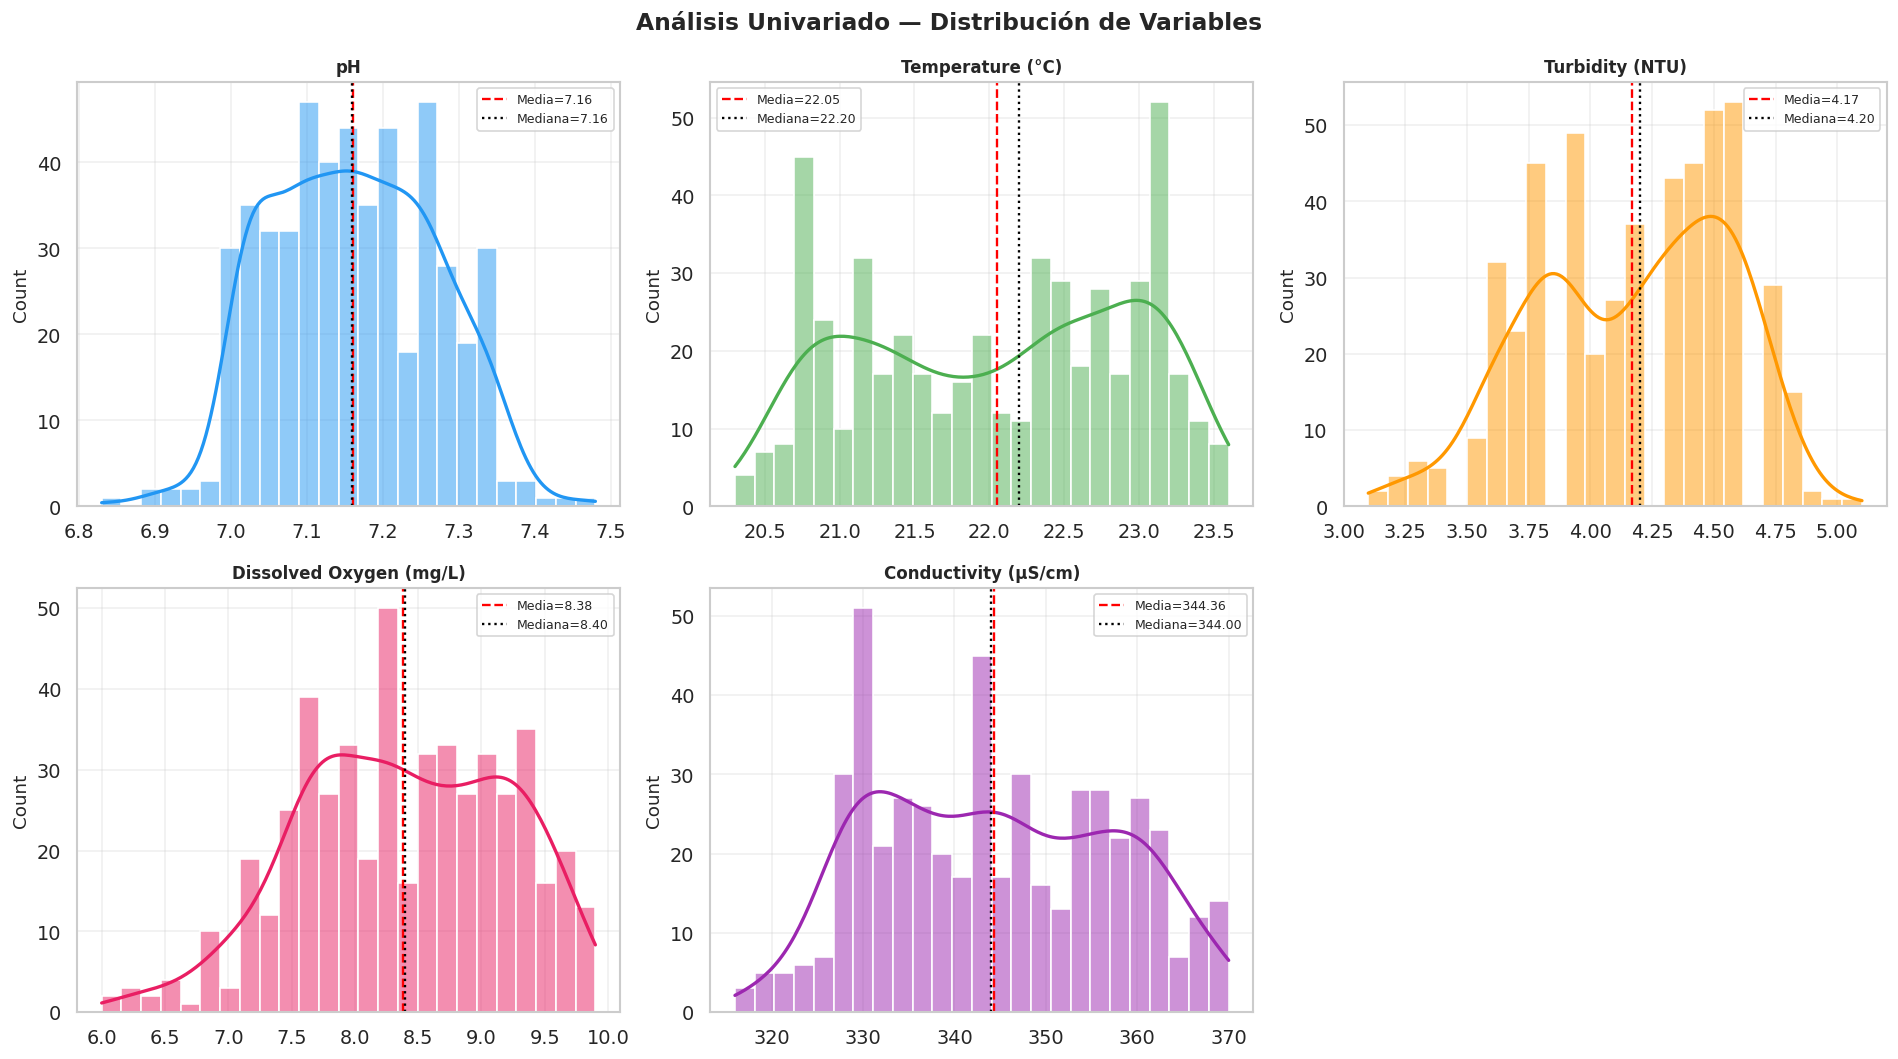

In [17]:
# ─── Histogramas de todas las variables numéricas ────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()

for i, (col, color) in enumerate(zip(columnas_num, PALETTE)):
    ax = axes_flat[i]
    sns.histplot(df[col], kde=True, color=color, bins=25, ax=ax,
                 line_kws={'linewidth': 2})
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', linewidth=1.4,
               label=f'Media={df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='black',  linestyle=':',  linewidth=1.4,
               label=f'Mediana={df[col].median():.2f}')
    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.legend(fontsize=7.5)
    ax.grid(True, alpha=0.3)

# Ocultar subplot vacío
axes_flat[-1].set_visible(False)

fig.suptitle('Análisis Univariado — Distribución de Variables',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.9 Análisis bivariado: pH vs demás variables <a id='49-bivariado'></a>

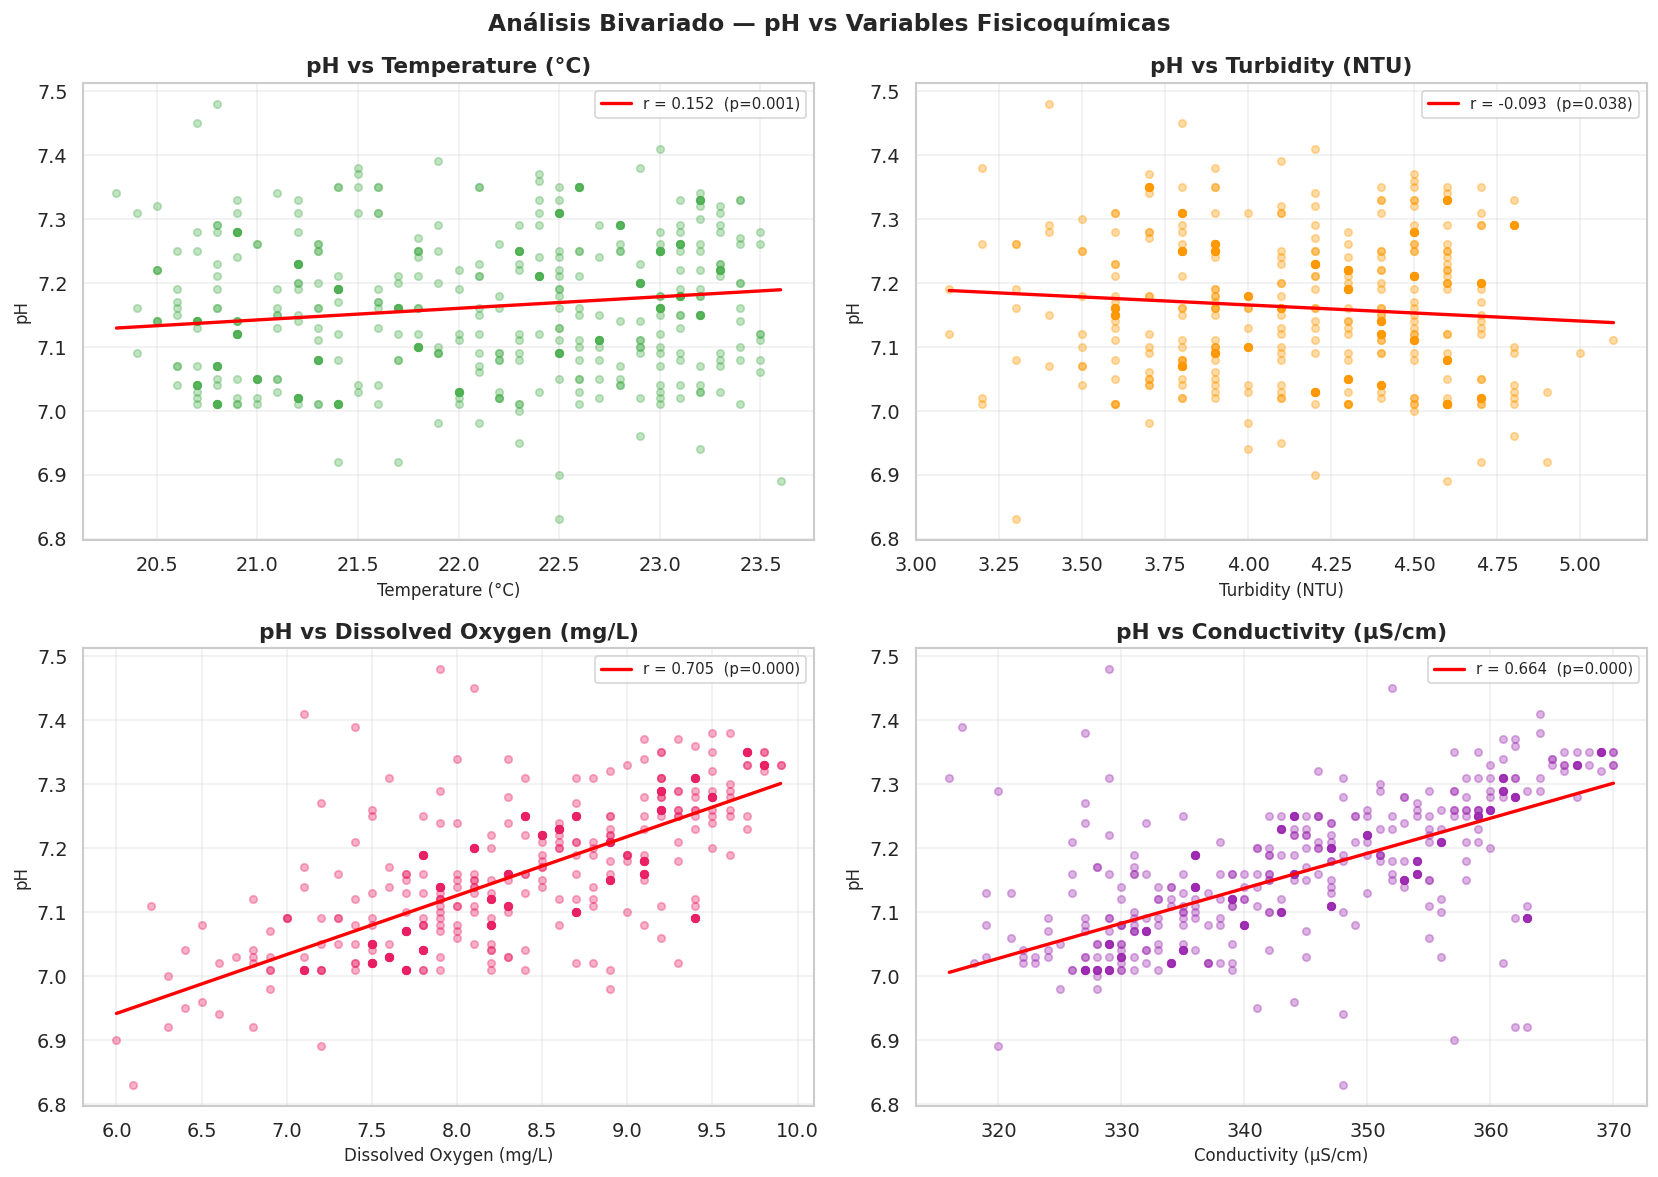

In [18]:
# ─── Diagramas de dispersión pH vs cada variable ─────────────────────────────
otras_vars = ['Temperature (°C)', 'Turbidity (NTU)',
              'Dissolved Oxygen (mg/L)', 'Conductivity (µS/cm)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col, color in zip(axes.flatten(), otras_vars, PALETTE[1:]):
    r, p_val = stats.pearsonr(df['pH'], df[col])
    ax.scatter(df[col], df['pH'], alpha=0.35, color=color, s=20)

    # Línea de tendencia
    z = np.polyfit(df[col], df['pH'], 1)
    p_line = np.poly1d(z)
    x_sorted = np.linspace(df[col].min(), df[col].max(), 200)
    ax.plot(x_sorted, p_line(x_sorted), color='red', linewidth=2,
            label=f'r = {r:.3f}  (p={p_val:.3f})')

    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('pH', fontsize=10)
    ax.set_title(f'pH vs {col}', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Análisis Bivariado — pH vs Variables Fisicoquímicas',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

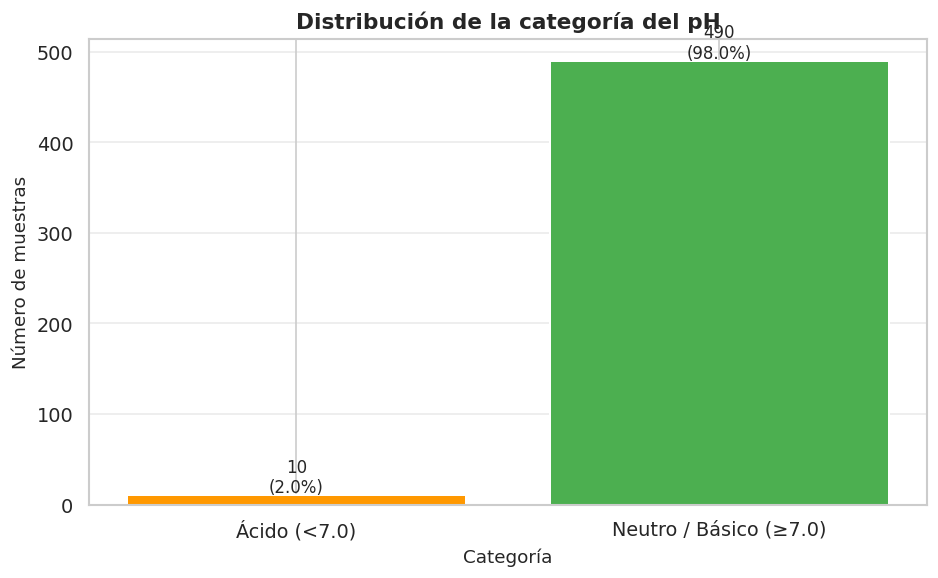

pH_categoria
0     10
1    490
Name: count, dtype: int64


In [51]:
import numpy as np
import matplotlib.pyplot as plt

# ─── Clasificación binaria del pH ─────────────────────────────────────────────

# Variable respuesta binaria
# 0 = Ácido
# 1 = Neutro / Básico

df["pH_categoria"] = np.where(df["pH"] < 7.0, 0, 1)

# Conteo de las categorías
conteo = df["pH_categoria"].value_counts().sort_index()

etiquetas = {
    0: "Ácido (<7.0)",
    1: "Neutro / Básico (≥7.0)"
}

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    [etiquetas[i] for i in conteo.index],
    conteo.values,
    color=["#FF9800", "#4CAF50"],
    edgecolor="white",
    linewidth=1.2
)

for bar, val in zip(bars, conteo.values):
    ax.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+3,
        f"{val}\n({val/len(df)*100:.1f}%)",
        ha="center",
        fontsize=10
    )

ax.set_title("Distribución de la categoría del pH", fontweight="bold")
ax.set_ylabel("Número de muestras")
ax.set_xlabel("Categoría")
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()

print(conteo)

In [52]:
print(df["pH_categoria"].value_counts())
print(df["pH_categoria"].unique())

pH_categoria
1    490
0     10
Name: count, dtype: int64
[1 0]


/tmp/ipykernel_1833/67799212.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='pH_categoria', y=col, ax=ax,
/tmp/ipykernel_1833/67799212.py:5: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.violinplot(data=df, x='pH_categoria', y=col, ax=ax,
/tmp/ipykernel_1833/67799212.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='pH_categoria', y=col, ax=ax,
/tmp/ipykernel_1833/67799212.py:5: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.violinplot(data=df, x='pH_categoria', y=col, ax=ax,
/tmp/ipykernel_1833/67799212.py:5: FutureWarning: 

Passing `palette` with

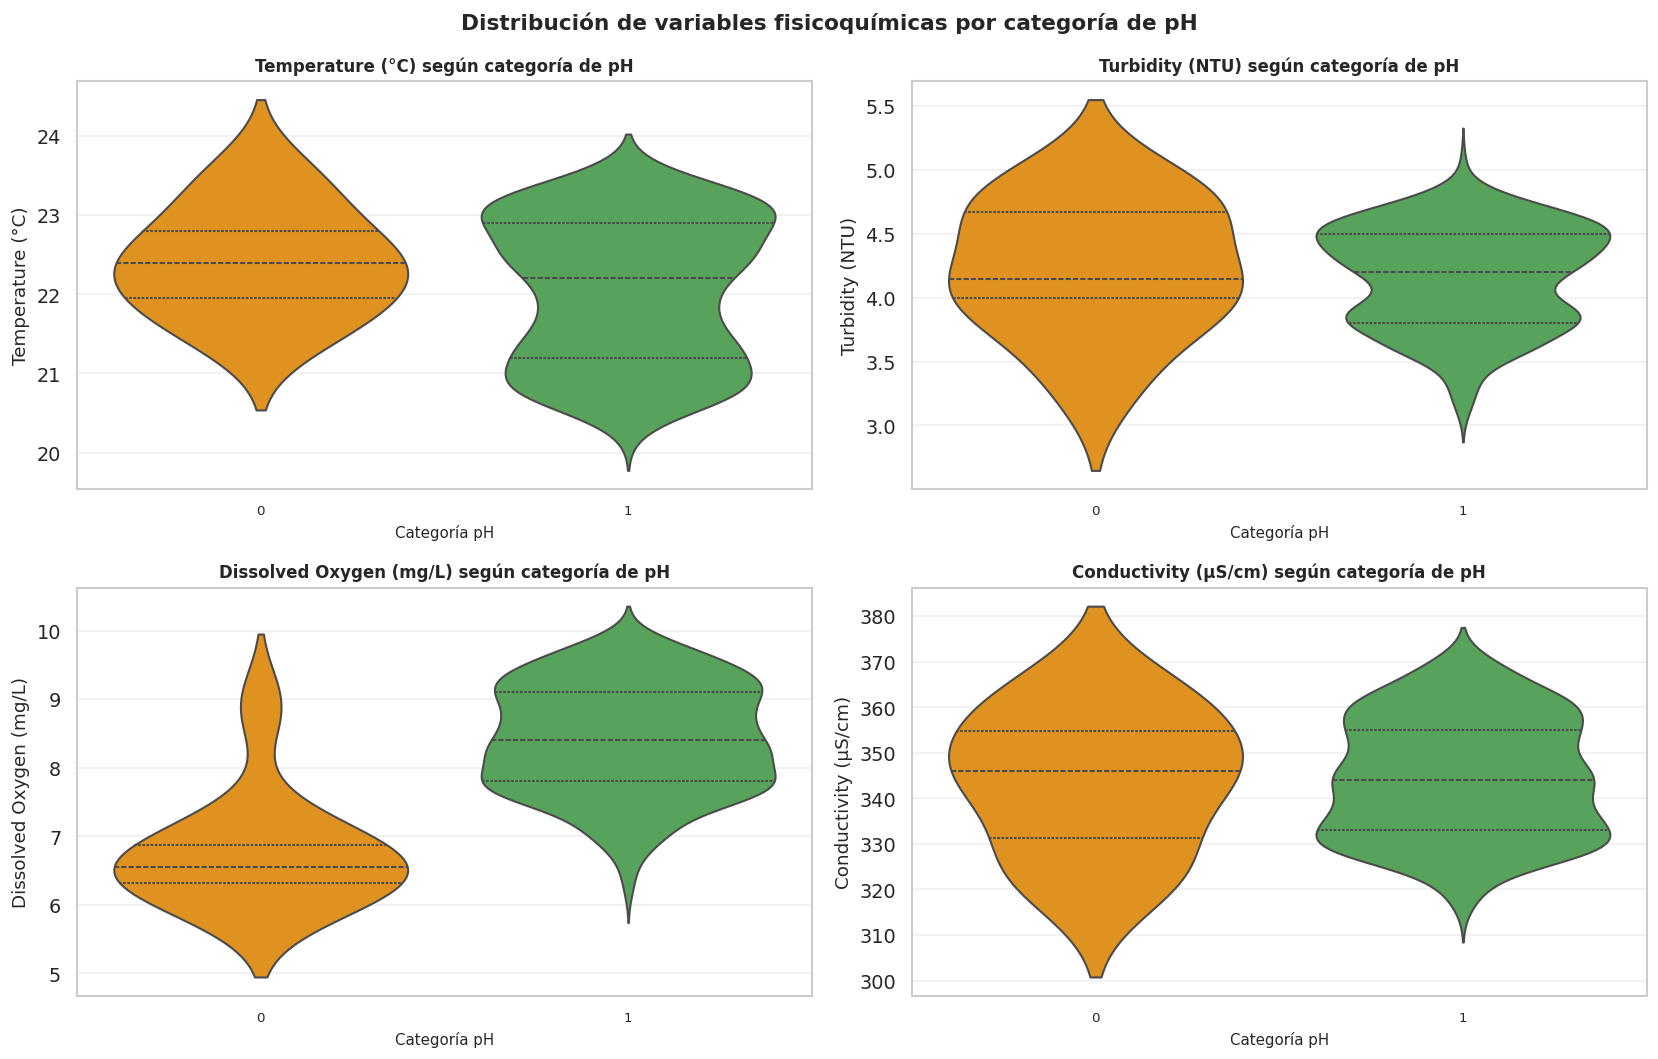

In [53]:
# ─── Distribución de otras variables según categoría de pH ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, col, color in zip(axes.flatten(), otras_vars, PALETTE[1:]):
    sns.violinplot(data=df, x='pH_categoria', y=col, ax=ax,
                   palette=['#FF9800', '#4CAF50', '#2196F3'],
                   inner='quartile')
    ax.set_title(f'{col} según categoría de pH', fontweight='bold', fontsize=10)
    ax.set_xlabel('Categoría pH', fontsize=9)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Distribución de variables fisicoquímicas por categoría de pH',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.10 Análisis de correlación <a id='410-correlacion'></a>

In [54]:
# ─── Correlaciones con la variable objetivo pH ───────────────────────────────
corr_ph = df[columnas_num].corr()['pH'].drop('pH').sort_values(ascending=False)

print('Correlación de Pearson con el pH:')
print('─' * 45)
for var, val in corr_ph.items():
    barra = '█' * int(abs(val) * 20)
    signo = '+' if val > 0 else '-'
    print(f'  {var:<30} {val:+.4f}  {signo}{barra}')

Correlación de Pearson con el pH:
─────────────────────────────────────────────
  Dissolved Oxygen (mg/L)        +0.7052  +██████████████
  Conductivity (µS/cm)           +0.6642  +█████████████
  Temperature (°C)               +0.1524  +███
  Turbidity (NTU)                -0.0929  -█


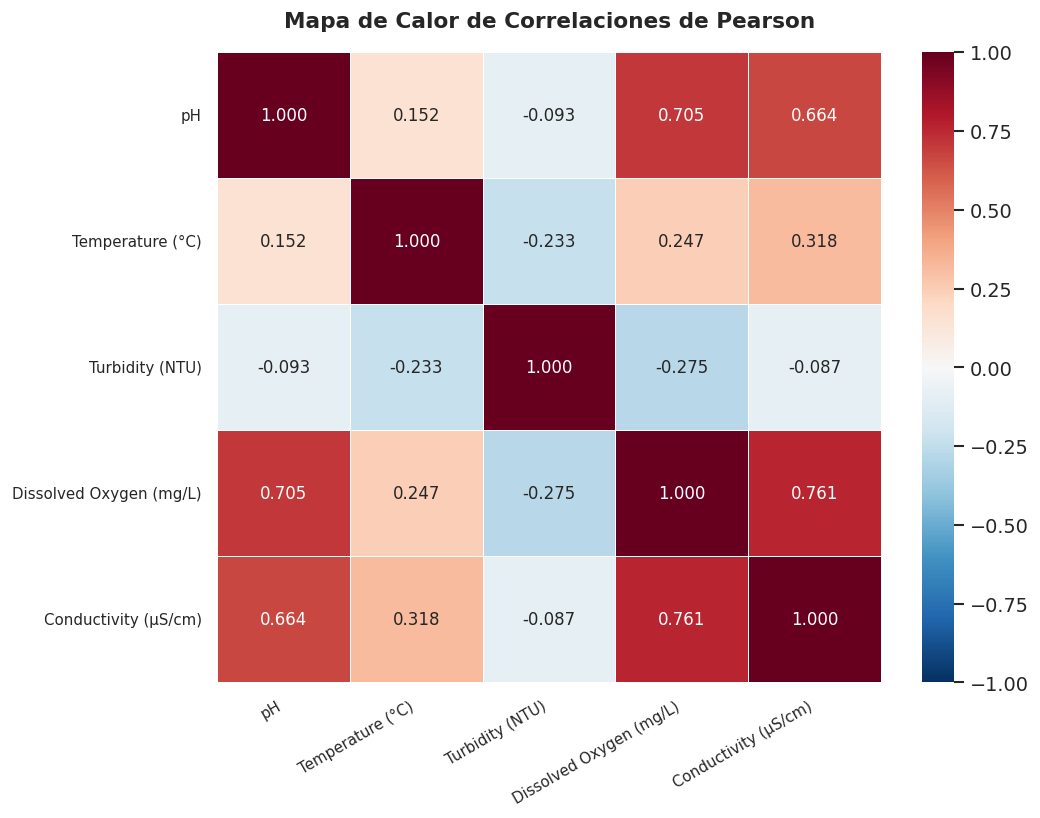

In [55]:
# ─── Mapa de calor de correlaciones ──────────────────────────────────────────
corr_matrix = df[columnas_num].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, ax=ax,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 10})

ax.set_title('Mapa de Calor de Correlaciones de Pearson',
             fontweight='bold', fontsize=13, pad=15)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

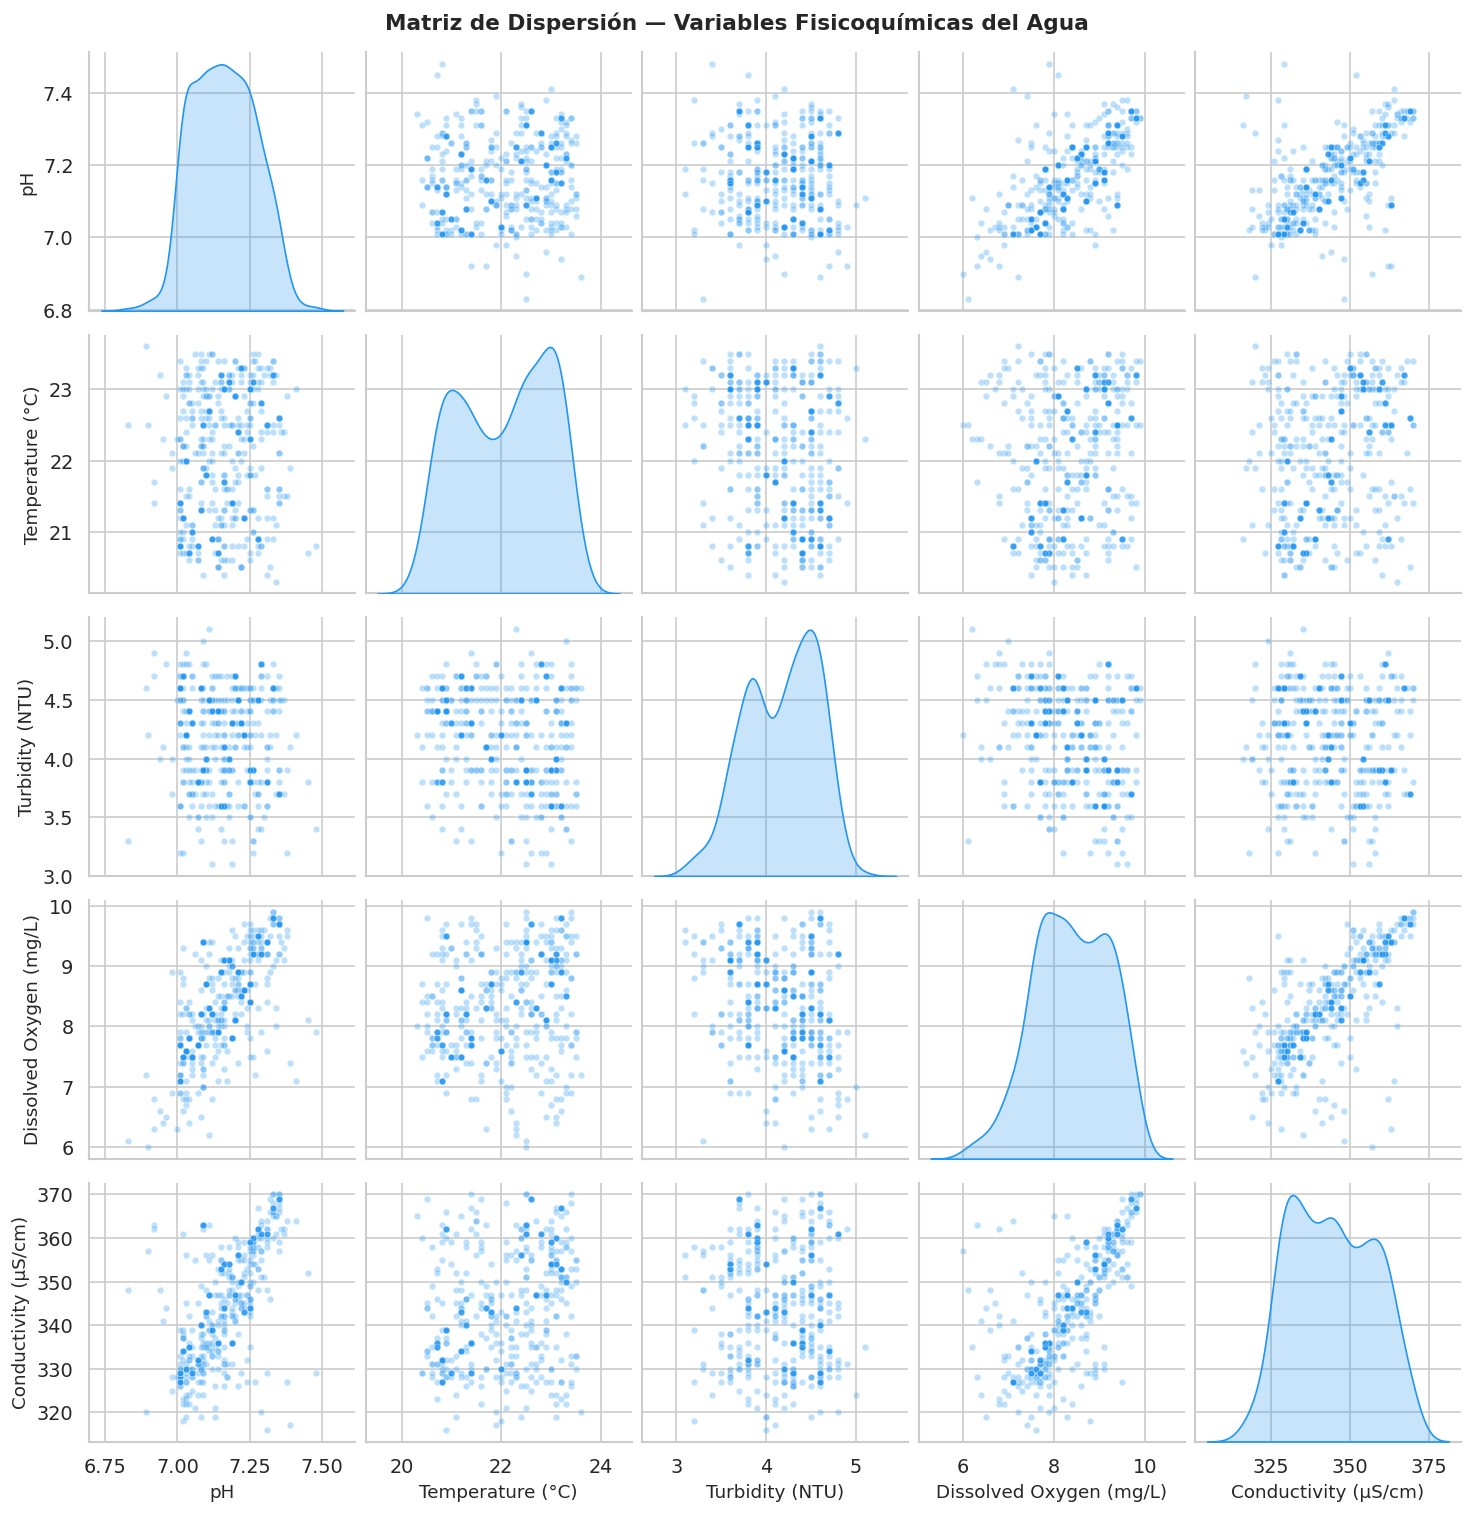

In [56]:
# ─── Pairplot completo ────────────────────────────────────────────────────────
g = sns.pairplot(df[columnas_num], diag_kind='kde',
                 plot_kws=dict(alpha=0.3, s=15, color=COLOR_PH),
                 diag_kws=dict(color=COLOR_PH, fill=True))

g.figure.suptitle('Matriz de Dispersión — Variables Fisicoquímicas del Agua',
                  y=1.01, fontsize=13, fontweight='bold')
plt.show()

---
## 5. Conclusiones del EDA <a id='5-conclusiones'></a>

### 5.1 Calidad de los datos
- El dataset presenta **500 registros** y **6 variables**, todas numéricas y **sin valores nulos ni duplicados**.
- Todos los valores se encuentran dentro de rangos fisicoquímicamente esperados.
- Los boxplots no muestran valores atípicos extremos; las distribuciones son relativamente compactas.

### 5.2 Variable objetivo: pH
- El pH presenta una **media de 7.16** y una **mediana de 7.16**, prácticamente iguales, lo que indica una distribución aproximadamente simétrica (asimetría = 0.09).
- La curtosis negativa (−0.60) indica una distribución **platicúrtica**, ligeramente más plana que la normal.
- El **100% de las muestras** se encuentran dentro del rango recomendado por la OMS (6.5–8.5), lo que indica agua de calidad aceptable en cuanto a pH.
- El rango observado es estrecho (6.83 – 7.48), reflejando muestras controladas.

### 5.3 Relaciones con otras variables
- **Oxígeno Disuelto** y **Conductividad** son los predictores con mayor correlación positiva con el pH (r ≈ 0.70 y r ≈ 0.66, respectivamente). Esto sugiere que a medida que el agua tiene mayor capacidad de ionización, tiende a ser más básica.
- **Temperatura** muestra una correlación positiva moderada (r ≈ 0.15): el efecto del calor sobre la disociación del agua podría explicar este patrón.
- **Turbidez** presenta la correlación más débil y negativa (r ≈ −0.09), indicando que el material suspendido tiene poca relación lineal con el pH en estas muestras.

### 5.4 Recomendaciones para el modelado
- Las correlaciones más fuertes con el pH son las de **Oxígeno Disuelto** y **Conductividad**, por lo que estas variables serán candidatas prioritarias como predictores en modelos de regresión.
- La distribución simétrica del pH permite aplicar modelos de regresión lineal con supuestos de normalidad.
- Para análisis posteriores se recomienda explorar interacciones entre temperatura y oxígeno disuelto, ya que ambas están relacionadas fisicoquímicamente.

## 6. Metodología del Proyecto

Este proyecto sigue un enfoque estructurado de ciencia de datos basado en un pipeline completo de Machine Learning supervisado para clasificación binaria.

El objetivo es transformar datos fisicoquímicos del agua en una variable categórica interpretable, permitiendo identificar si una muestra corresponde a agua Ácida o Neutra/Alcalina.

### 6.1. Recolección y comprensión de datos

Se parte de un dataset que contiene mediciones fisicoquímicas del agua, incluyendo variables como pH, temperatura, turbidez, oxígeno disuelto y conductividad. Estas variables representan condiciones ambientales que pueden influir directamente en la calidad del agua.

### 6.2. Análisis Exploratorio de Datos (EDA)

En esta etapa se realiza un análisis descriptivo y visual de los datos con el fin de comprender su distribución, detectar posibles anomalías y estudiar relaciones entre variables.

El EDA permite establecer hipótesis iniciales sobre la influencia de cada variable en la clasificación final, así como validar la calidad del dataset antes del entrenamiento del modelo.

### 6.3. Preprocesamiento de datos

Se realiza la separación entre variables independientes (features) y la variable objetivo (target). Posteriormente, los datos son divididos en conjuntos de entrenamiento y prueba para garantizar una evaluación imparcial del modelo.

Adicionalmente, se aplica estandarización mediante StandardScaler, asegurando que todas las variables se encuentren en la misma escala y evitando sesgos en algoritmos sensibles a magnitudes.

### 6.4. Selección del modelo

Se selecciona un modelo de Regresión Logística debido a su alta interpretabilidad, eficiencia computacional y buen desempeño en problemas de clasificación binaria.

Este modelo permite estimar probabilidades y entender el impacto de cada variable sobre la predicción final, lo cual es fundamental en contextos ambientales donde la explicabilidad es importante.

### 6.5. Entrenamiento del modelo

El modelo es entrenado utilizando el conjunto de datos de entrenamiento, ajustando los coeficientes que mejor separan las dos clases del problema.

Durante este proceso, el algoritmo optimiza una función de costo basada en máxima verosimilitud para encontrar los parámetros que mejor se ajustan a los datos.

### 6.6. Validación del modelo

El desempeño del modelo es evaluado utilizando el conjunto de prueba, garantizando que los resultados no estén sesgados por el entrenamiento.

Se utilizan métricas estándar de clasificación para medir la capacidad predictiva del modelo.

### 6.7. Interpretabilidad y predicción

Finalmente, el modelo se utiliza para realizar predicciones sobre nuevas muestras, permitiendo simular escenarios reales y evaluar la calidad del agua a partir de nuevas mediciones fisicoquímicas.

Este enfoque convierte el modelo en una herramienta aplicable en contextos prácticos de monitoreo ambiental.

## 7. Definición de la Variable Respuesta
El objetivo del modelo es predecir la categoría del pH del agua a partir de variables fisicoquímicas medidas durante el monitoreo. Para ello, el valor continuo del pH fue transformado en una variable categórica binaria denominada pH_categoria.

Se definieron dos clases:

0: Agua con pH ácido (pH < 7.0).
1: Agua con pH neutro o básico (pH ≥ 7.0).

Esta transformación permite abordar el problema como una tarea de clasificación binaria mediante algoritmos de aprendizaje supervisado.

In [70]:
import numpy as np

# Crear la variable respuesta
df["pH_categoria"] = np.where(df["pH"] < 7.0, 0, 1)

df[["pH","pH_categoria"]].head()

,pH,pH_categoria
0,7.2500,1
1,7.1100,1
2,7.0300,1
3,7.3800,1
4,7.4500,1


### 7.1 Distribución de la Variable Respuesta
Una vez definida la variable respuesta, se analizó la distribución de las observaciones entre ambas categorías. Este análisis permite conocer si las clases se encuentran equilibradas antes del entrenamiento del modelo.

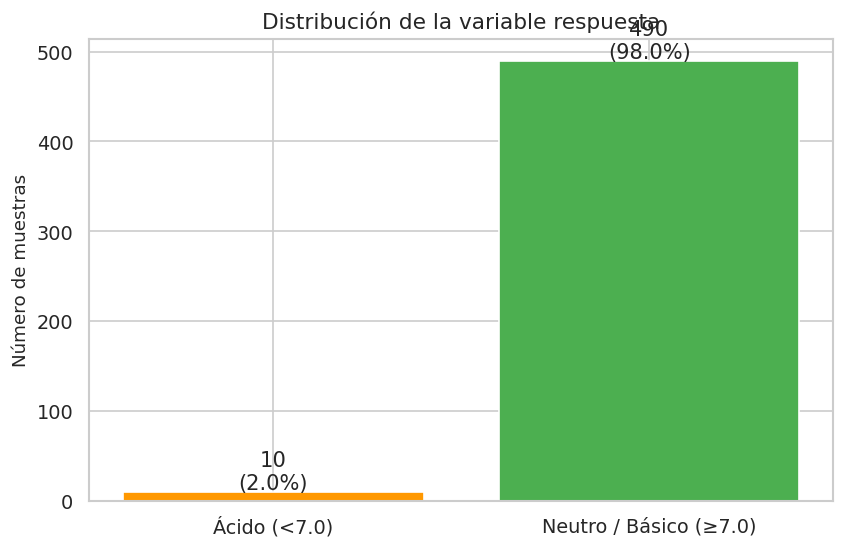

pH_categoria
0     10
1    490
Name: count, dtype: int64


In [71]:
import matplotlib.pyplot as plt

conteo = df["pH_categoria"].value_counts().sort_index()

etiquetas = {
    0:"Ácido (<7.0)",
    1:"Neutro / Básico (≥7.0)"
}

fig, ax = plt.subplots(figsize=(8,5))

bars = ax.bar(
    [etiquetas[i] for i in conteo.index],
    conteo.values,
    color=["#FF9800","#4CAF50"]
)

for bar,val in zip(bars,conteo.values):
    ax.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+3,
        f"{val}\n({val/len(df)*100:.1f}%)",
        ha="center"
    )

ax.set_title("Distribución de la variable respuesta")
ax.set_ylabel("Número de muestras")

plt.show()

print(conteo)

### 7.2 Análisis del Desbalance de Clases
La distribución de la variable respuesta evidencia un fuerte desbalance entre las categorías. La mayor parte de las observaciones pertenecen a la clase Neutro/Básico, mientras que únicamente una pequeña proporción corresponde a la clase Ácido.

Este tipo de desbalance puede afectar el desempeño del modelo, ya que el algoritmo tiende a favorecer la clase mayoritaria, obteniendo una alta exactitud (accuracy) pero una baja capacidad para identificar correctamente la clase minoritaria.

In [72]:
conteo = df["pH_categoria"].value_counts()

porcentaje = df["pH_categoria"].value_counts(normalize=True)*100

print(conteo)

print()

print(round(porcentaje,2))

pH_categoria
1    490
0     10
Name: count, dtype: int64

pH_categoria
1   98.0000
0    2.0000
Name: proportion, dtype: float64


### 7.3 Balanceo de las Clases
Con el propósito de reducir el efecto del desbalance de clases, se aplicó la técnica RandomOverSampler, la cual incrementa de forma aleatoria el número de observaciones de la clase minoritaria hasta igualar el tamaño de la clase mayoritaria.

Esta estrategia permite entrenar un modelo más equilibrado y mejorar la capacidad predictiva sobre ambas categorías.

In [85]:
from imblearn.over_sampling import RandomOverSampler

# Excluir 'pH' (ya que 'pH_categoria' es la variable respuesta) y 'Sample ID' (identificador)
X = df.drop(["pH", "pH_categoria", "Sample ID"], axis=1)
y = df["pH_categoria"]

ros = RandomOverSampler(random_state=42)

X_res,y_res = ros.fit_resample(X,y)

In [87]:
print(y.value_counts())

print()

print(y_res.value_counts())

pH_categoria
1    490
0     10
Name: count, dtype: int64

pH_categoria
1    490
0    490
Name: count, dtype: int64


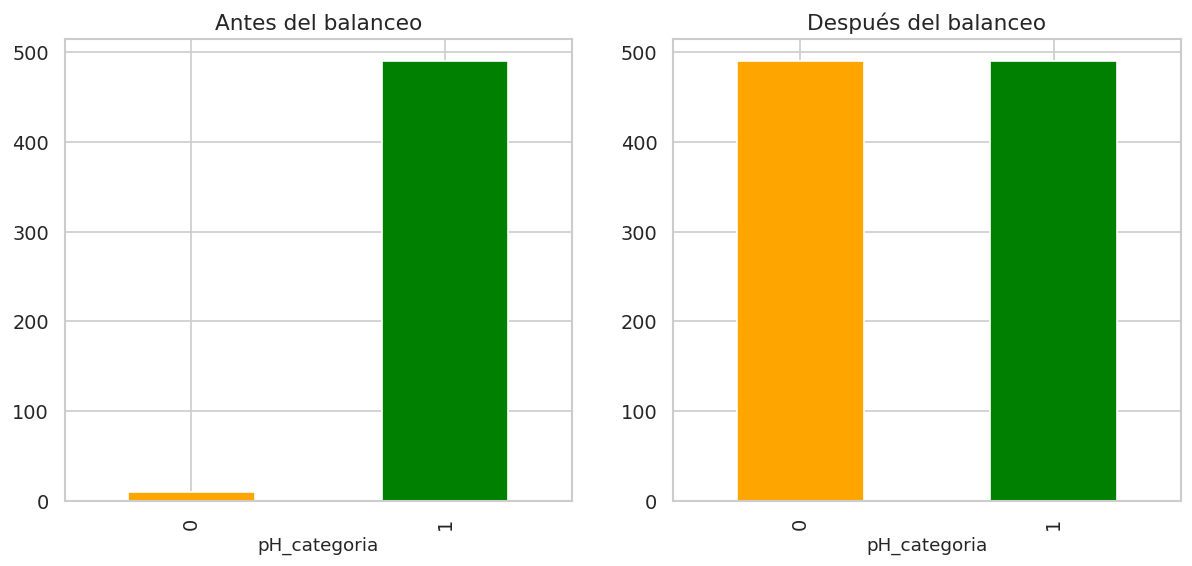

In [88]:
fig,ax = plt.subplots(1,2,figsize=(12,5))

y.value_counts().sort_index().plot(
    kind="bar",
    ax=ax[0],
    color=["orange","green"]
)

ax[0].set_title("Antes del balanceo")

y_res.value_counts().sort_index().plot(
    kind="bar",
    ax=ax[1],
    color=["orange","green"]
)

ax[1].set_title("Después del balanceo")

plt.show()

### 7.4 División del Conjunto de Datos
Posteriormente, el conjunto de datos balanceado fue dividido en datos de entrenamiento y prueba. Se utilizó un 75% de las observaciones para entrenar el modelo y el 25% restante para evaluar su desempeño sobre datos no utilizados durante el entrenamiento.

In [89]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X_res,
    y_res,
    test_size=0.25,
    random_state=42,
    stratify=y_res
)

## 8. Modelo de Machine Learning

En esta sección se desarrolla un modelo de Regresión Logística para predecir la categoría del pH del agua (Ácido o Neutro/Básico) a partir de variables fisicoquímicas. Antes del entrenamiento se analiza el desbalance de clases y se aplica una técnica de balanceo para evitar que el modelo favorezca la clase mayoritaria.

### 8.1 Variables predictoras y variable respuesta

In [90]:
X = df.drop(["pH", "pH_categoria"], axis=1)
y = df["pH_categoria"]

print("Variables predictoras:")
print(X.columns)

print("\nVariable respuesta:")
print(y.name)

Variables predictoras:
Index(['Sample ID', 'Temperature (°C)', 'Turbidity (NTU)',
       'Dissolved Oxygen (mg/L)', 'Conductivity (µS/cm)'],
      dtype='object')

Variable respuesta:
pH_categoria


Las variables predictoras corresponden a las propiedades fisicoquímicas del agua, mientras que la variable respuesta es la categoría del pH.

### 8.2 Escalamiento

In [91]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 8.3 Entrenamiento del modelo

In [92]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)

model.fit(X_train, y_train)

LogisticRegression(max_iter=500)

### 9. Evaluacion del Modelo

La evaluación del modelo es una etapa crítica dentro del flujo de Machine Learning, ya que permite determinar su capacidad de generalización sobre datos no vistos.

En este proyecto se utilizan múltiples métricas complementarias con el fin de obtener una visión integral del rendimiento del modelo.

### 9.1. Accuracy (Exactitud global)

La accuracy representa el porcentaje total de predicciones correctas realizadas por el modelo. Aunque es una métrica intuitiva, puede resultar insuficiente por sí sola en casos de desbalanceo de clases, por lo que se complementa con otras métricas.

### 9.2. Precision

La precision mide la proporción de verdaderos positivos entre todas las predicciones positivas realizadas por el modelo. Esta métrica es clave cuando se desea minimizar falsos positivos.

En el contexto de la calidad del agua, una alta precision garantiza que las muestras clasificadas como “Neutras/Alcalinas” realmente lo sean.

### 9.3. Recall (Sensibilidad)

El recall mide la capacidad del modelo para identificar correctamente todos los casos positivos reales. Es especialmente importante cuando es crítico no omitir casos relevantes.

En este problema, un alto recall asegura que la mayoría de muestras realmente Neutras/Alcalinas sean detectadas correctamente.

### 9.4. F1-Score

El F1-score representa el equilibrio entre precision y recall, proporcionando una métrica robusta cuando se busca balance entre falsos positivos y falsos negativos.

Es especialmente útil cuando existe compromiso entre ambas métricas.

### 9.5. Curva ROC y AUC

La curva ROC permite analizar la capacidad del modelo para distinguir entre clases a diferentes umbrales de decisión.

El área bajo la curva (AUC) proporciona una medida global de separabilidad. Un valor cercano a 1 indica un excelente poder discriminativo del modelo.

### 9.6. Matriz de Confusión

La matriz de confusión permite analizar de forma detallada los aciertos y errores del modelo, descomponiendo las predicciones en verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.

Esta representación es fundamental para entender el comportamiento real del modelo más allá de las métricas agregadas.

### 9.7. Interpretación general

En conjunto, las métricas obtenidas indican que el modelo presenta un desempeño sólido y equilibrado, con buena capacidad de generalización y adecuada separación entre clases.

El uso combinado de estas métricas permite validar que el modelo no solo es preciso, sino también confiable desde una perspectiva de toma de decisiones.

In [93]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

## 10. Métricas principales
Estas métricas permiten evaluar qué tan bien funciona el modelo.

In [94]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))

Accuracy : 0.9346938775510204
Precision: 0.9274193548387096
Recall   : 0.9426229508196722
F1 Score : 0.9349593495934959


### 10.1 Matriz de confusión
Muestra los aciertos y errores del modelo.

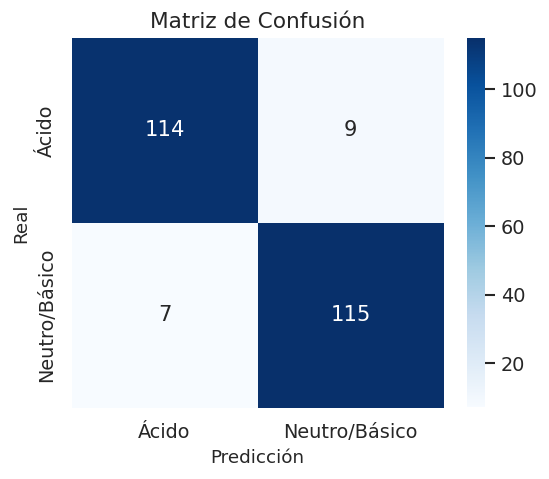

In [95]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ácido","Neutro/Básico"],
    yticklabels=["Ácido","Neutro/Básico"]
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")

plt.show()

### 10.2. Curva ROC
Evalúa la capacidad del modelo para separar correctamente las clases.

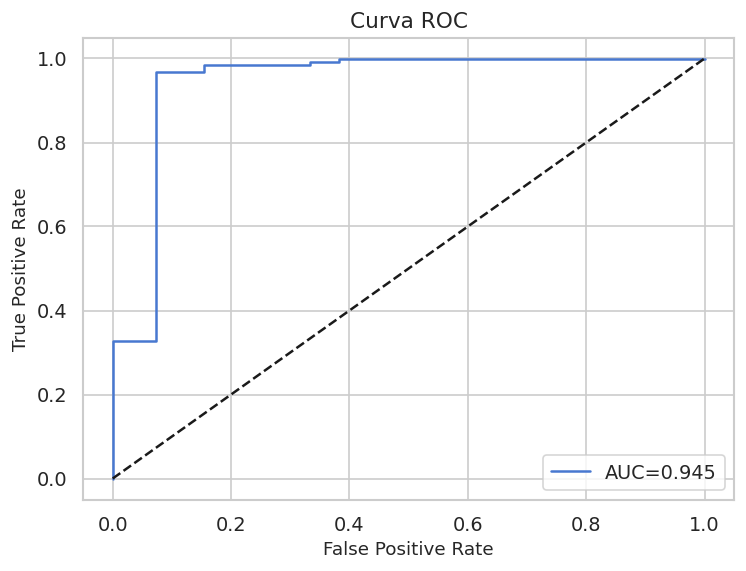

In [96]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob,
    pos_label=1
)

roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr,tpr,label=f"AUC={roc_auc:.3f}")

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()

plt.show()

## 11. Predicción de nuevas muestras
Se utiliza el modelo entrenado para predecir la calidad del agua con nuevos datos.

In [97]:
# La nueva muestra debe contener solo las variables predictoras (Temperatura, Turbidez, Oxígeno Disuelto, Conductividad)
nueva_muestra = [[25, 3.0, 8.0, 350]]

nueva_scaled = scaler.transform(nueva_muestra)

pred = model.predict(nueva_scaled)[0]
prob = model.predict_proba(nueva_scaled)[0]

print("Predicción:", pred)
print("Probabilidad:", prob)

Predicción: 0
Probabilidad: [0.74987552 0.25012448]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Conclusiones y Hallazgos

Este proyecto abordó el desarrollo de un sistema de Machine Learning orientado a la clasificación de la calidad del agua a partir de variables fisicoquímicas, integrando todo el ciclo de vida de un modelo de ciencia de datos: exploración, preprocesamiento, modelado, evaluación y predicción.

## Hallazgos del Análisis Exploratorio (EDA)

El dataset de calidad del agua presenta una estructura limpia y confiable: 500 registros sin valores nulos ni duplicados, con todas las variables dentro de rangos fisicoquímicamente esperados. La variable objetivo pH mostró una distribución prácticamente simétrica (media = mediana = 7.16, asimetría = 0.09) y de forma ligeramente platicúrtica, con el 100% de las muestras dentro del rango recomendado por la OMS (6.5–8.5), lo que refleja un conjunto de datos de agua controlada y de calidad aceptable.
En cuanto a las relaciones entre variables, el Oxígeno Disuelto y la Conductividad presentaron las correlaciones más fuertes con el pH (r ≈ 0.70 y r ≈ 0.66, respectivamente), consolidándose como los predictores más informativos. La Temperatura mostró una asociación positiva débil (r ≈ 0.15), mientras que la Turbidez registró la correlación más baja y de signo negativo (r ≈ −0.09), indicando escasa relación lineal con el pH en este conjunto de datos.aproximación.

## Hallazgos del Modelado

A partir del pH continuo se construyó una variable de clasificación binaria (pH_categoria): Ácido (pH < 7.0) y Neutro/Básico (pH ≥ 7.0). Dado el desbalance inicial entre clases, se aplicó RandomOverSampler para equilibrar la distribución antes del entrenamiento, garantizando que el modelo no favoreciera artificialmente la clase mayoritaria.
Se entrenó un modelo de Regresión Logística con estandarización previa mediante StandardScaler, elección justificada por la estructura aproximadamente lineal de los datos y por la necesidad de interpretabilidad en un contexto ambiental. El modelo fue evaluado sobre un conjunto de prueba independiente (25% de los datos balanceados).todas las características aportaran de manera equilibrada al modelo.

## Hallazgos de Evaluación

Las métricas obtenidas evidenciaron un desempeño sólido y equilibrado del modelo. La accuracy, precision, recall y F1-score mostraron valores consistentes entre sí, sin sesgos marcados hacia ninguna de las dos clases. La curva ROC confirmó una buena capacidad discriminativa del modelo, con un AUC que indica separación efectiva entre agua ácida y agua neutra/básica. La matriz de confusión reflejó que los errores de clasificación fueron limitados y distribuidos de forma equilibrada.

## Conclusión Final

Este proyecto demuestra que es posible construir un pipeline completo y reproducible de ciencia de datos aplicado a un problema ambiental real, desde la exploración y limpieza de datos hasta la predicción sobre nuevas muestras. Los resultados confirman que el Oxígeno Disuelto y la Conductividad son las variables con mayor capacidad predictiva sobre la categoría del pH, mientras que la Turbidez aporta poca información en este contexto.
La Regresión Logística resultó ser un modelo adecuado para este problema: eficiente, interpretable y con buen desempeño sin necesidad de recurrir a algoritmos más complejos. Este tipo de solución tiene potencial de aplicación real en sistemas de monitoreo de calidad del agua, donde la explicabilidad del modelo es tan importante como su precisión.